# Deliverable 3: Classification, Clustering, and Pattern Mining  
**Course:** MSCS-634 – Advanced Big Data & Data Mining  
**Name:** *Sudhanshu Sekhar Dash*  

This notebook implements:
- Classification models (Decision Tree, KNN)
- Hyperparameter tuning for KNN
- Model evaluation (Confusion Matrix, Accuracy, F1, ROC/AUC)
- Clustering (K-Means + PCA visualization)
- Association rule mining (Apriori + association rules)


In [1]:
# ---------------------------------
# IMPORTS & SETUP
# ---------------------------------
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    roc_curve,
    auc,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Association rule mining (install mlxtend if needed)
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
except ImportError:
    print("mlxtend not found. Install it with: pip install mlxtend")


In [2]:
# ---------------------------------
# LOAD DATA (CORRECTED)
# ---------------------------------
DATA_PATH = r"G:\UCumberlands\Data Mining\cleaned_healthcare_data.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (500, 10)


,Age,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,RiskLevel,TreatmentPlan,Diagnosis,Outcome
0,56,39.8,116,108,259,96,Medium,Intensive,Cardiac,1
1,69,21.1,144,84,229,91,Low,Intensive,Diabetes,1
2,46,29.4,122,188,203,107,Low,Intensive,NaN,1
3,32,37.3,157,98,274,102,Low,Intensive,Cardiac,0
4,60,34.3,155,144,280,96,Low,Intensive,Cardiac,0


In [3]:
# ---------------------------------
# BASIC EXPLORATION
# ---------------------------------
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            500 non-null    int64  
 1   BMI            500 non-null    float64
 2   BloodPressure  500 non-null    int64  
 3   GlucoseLevel   500 non-null    int64  
 4   Cholesterol    500 non-null    int64  
 5   HeartRate      500 non-null    int64  
 6   RiskLevel      500 non-null    object 
 7   TreatmentPlan  500 non-null    object 
 8   Diagnosis      387 non-null    object 
 9   Outcome        500 non-null    int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 39.2+ KB


In [4]:
df.describe(include="all").transpose().head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,500.0,NaN,NaN,NaN,49.91,18.221909,18.0,35.0,50.0,66.0,79.0
BMI,500.0,NaN,NaN,NaN,28.9462,6.459134,18.2,23.3,29.1,34.6,40.0
BloodPressure,500.0,NaN,NaN,NaN,124.402,19.841264,90.0,107.0,125.0,142.0,159.0
GlucoseLevel,500.0,NaN,NaN,NaN,133.078,38.463734,70.0,100.0,133.0,166.0,199.0
Cholesterol,500.0,NaN,NaN,NaN,228.774,44.914737,151.0,191.0,231.0,268.25,299.0
HeartRate,500.0,NaN,NaN,NaN,85.204,14.438397,60.0,73.0,86.0,97.25,109.0
RiskLevel,500,3,Low,177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TreatmentPlan,500,3,Standard,175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diagnosis,387,3,Diabetes,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outcome,500.0,NaN,NaN,NaN,0.522,0.500016,0.0,0.0,1.0,1.0,1.0


In [5]:
# ---------------------------------
# FEATURE / TARGET SPLIT
# ---------------------------------
# Change 'Outcome' to your actual target column name
target_col = "Outcome"  # <- change this if your target variable has a different name

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataset. Please update target_col.")

X = df.drop(columns=[target_col])
y = df[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((400, 9), (100, 9))

In [6]:
# ---------------------------------
# CLASSIFICATION MODEL 1: DECISION TREE (CORRECTED)
# ---------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify numeric and categorical columns
num_features = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_features = X_train.select_dtypes(include=["object", "category"]).columns

# Preprocessing: scale numeric + one-hot encode categorical
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

dt_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("clf", DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)

# For ROC (binary classification only)
if len(np.unique(y_train)) == 2:
    y_prob_dt = dt_pipeline.predict_proba(X_test)[:, 1]
else:
    y_prob_dt = None
    print("ROC/AUC only available for binary classification.")


In [7]:
# ---------------------------------
# CLASSIFICATION MODEL 2: KNN (BASELINE) - CORRECTED
# ---------------------------------
# This assumes you already ran:
# - import numpy as np
# - the preprocess = ColumnTransformer(...) definition used for Decision Tree

knn_pipeline = Pipeline([
    ("preprocess", preprocess),           # handles numeric + categorical
    ("clf", KNeighborsClassifier())
])

knn_pipeline.fit(X_train, y_train)
y_pred_knn = knn_pipeline.predict(X_test)

# For ROC (binary classification only)
if len(np.unique(y_train)) == 2:
    y_prob_knn = knn_pipeline.predict_proba(X_test)[:, 1]
else:
    y_prob_knn = None
    print("ROC/AUC only available for binary classification.")


In [8]:
# ---------------------------------
# HYPERPARAMETER TUNING: KNN WITH GRIDSEARCHCV
# ---------------------------------
param_grid = {
    "clf__n_neighbors": [3, 5, 7, 9, 11],
    "clf__weights": ["uniform", "distance"],
    "clf__metric": ["euclidean", "manhattan"],
}

knn_gs = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",  # change to 'accuracy' if you prefer
    n_jobs=-1
)

knn_gs.fit(X_train, y_train)

print("Best parameters:", knn_gs.best_params_)
print("Best CV F1 score:", knn_gs.best_score_)

best_knn = knn_gs.best_estimator_
y_pred_knn_best = best_knn.predict(X_test)

try:
    y_prob_knn_best = best_knn.predict_proba(X_test)[:, 1]
except AttributeError:
    y_prob_knn_best = None
    print("Best KNN model does not support predict_proba for this configuration or target type.")


Best parameters: {'clf__metric': 'manhattan', 'clf__n_neighbors': 5, 'clf__weights': 'distance'}
Best CV F1 score: 0.5476233222562686


In [9]:
# ---------------------------------
# EVALUATION HELPER FUNCTION
# ---------------------------------
def evaluate_model(y_true, y_pred, y_prob=None, model_name="Model"):
    print(f"=== {model_name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred, average="binary" if len(np.unique(y_true)) == 2 else "macro"))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()
    
    # ROC Curve (only if probabilities are provided and target is binary)
    if y_prob is not None and len(np.unique(y_true)) == 2:
        fpr, tpr, thresholds = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        
        plt.figure()
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{model_name} - ROC Curve")
        plt.legend()
        plt.show()
    else:
        print("ROC curve/AUC not computed (requires binary target and probability scores).")


=== Decision Tree ===
Accuracy: 0.49
F1 Score: 0.5048543689320388

Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.48      0.47        48
           1       0.51      0.50      0.50        52

    accuracy                           0.49       100
   macro avg       0.49      0.49      0.49       100
weighted avg       0.49      0.49      0.49       100



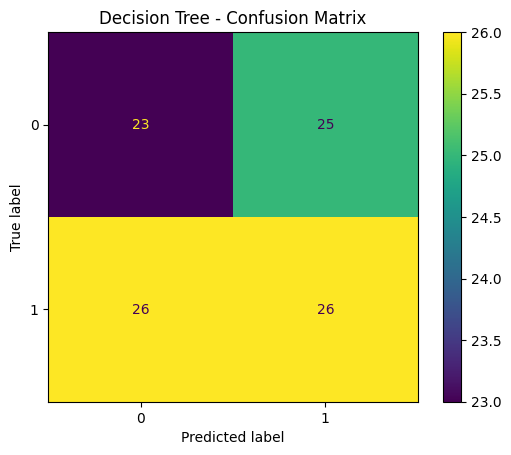

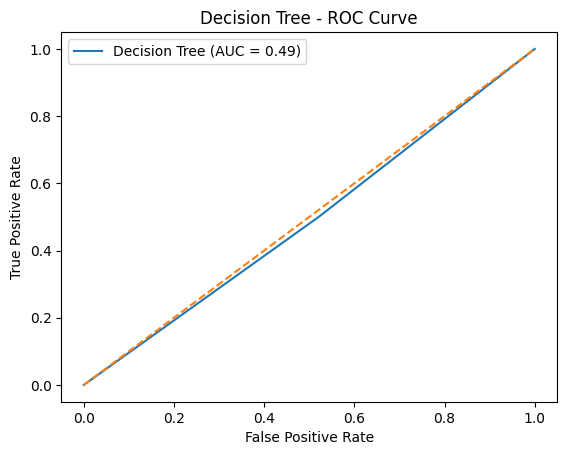

=== KNN (Baseline) ===
Accuracy: 0.57
F1 Score: 0.5981308411214953

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.52      0.54        48
           1       0.58      0.62      0.60        52

    accuracy                           0.57       100
   macro avg       0.57      0.57      0.57       100
weighted avg       0.57      0.57      0.57       100



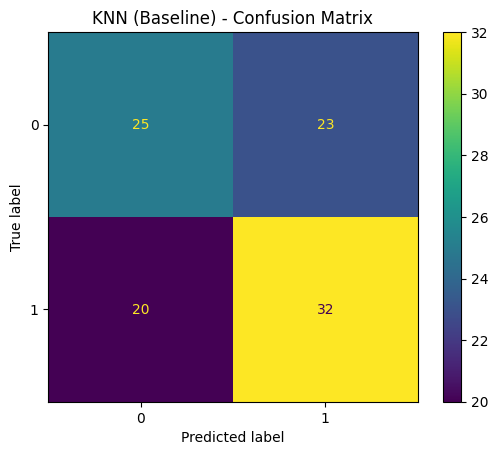

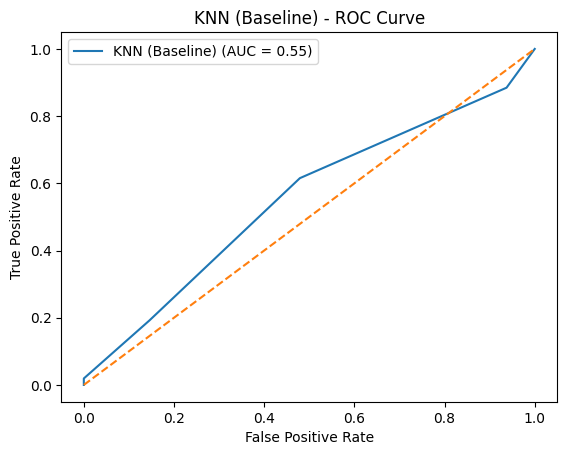

=== KNN (Tuned) ===
Accuracy: 0.52
F1 Score: 0.5384615384615384

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50        48
           1       0.54      0.54      0.54        52

    accuracy                           0.52       100
   macro avg       0.52      0.52      0.52       100
weighted avg       0.52      0.52      0.52       100



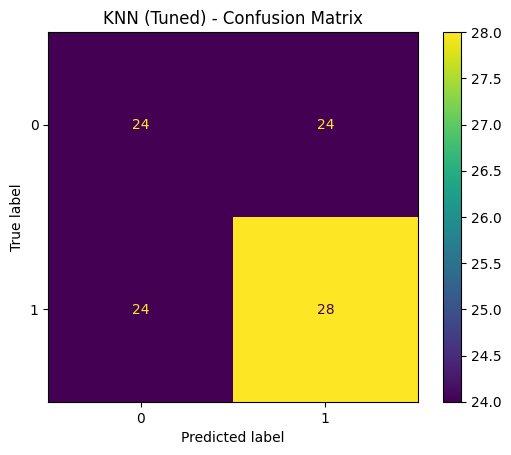

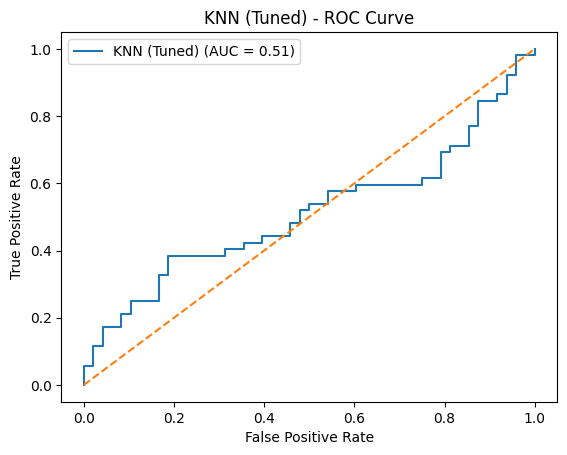

In [10]:
# ---------------------------------
# MODEL EVALUATION
# ---------------------------------
evaluate_model(y_test, y_pred_dt, y_prob_dt, model_name="Decision Tree")
evaluate_model(y_test, y_pred_knn, y_prob_knn, model_name="KNN (Baseline)")
evaluate_model(y_test, y_pred_knn_best, y_prob_knn_best, model_name="KNN (Tuned)")

Numeric features used for clustering: ['Age', 'BMI', 'BloodPressure', 'GlucoseLevel', 'Cholesterol', 'HeartRate']


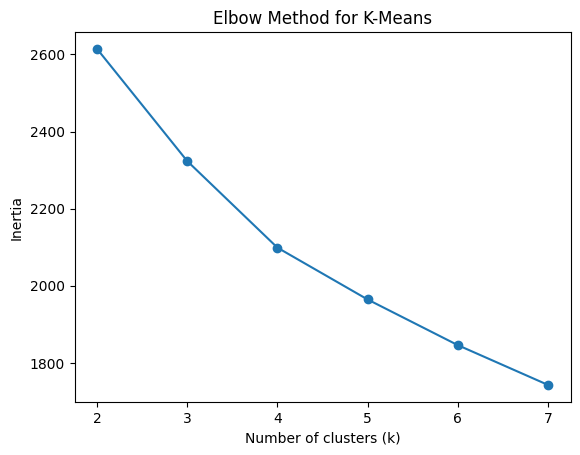

In [11]:
# ---------------------------------
# CLUSTERING: K-MEANS (ELBOW METHOD) - CORRECTED
# ---------------------------------
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Use only numeric columns for clustering
X_num = X.select_dtypes(include=["int64", "float64"])

print("Numeric features used for clustering:", list(X_num.columns))

scaler_clust = StandardScaler()
X_scaled = scaler_clust.fit_transform(X_num)

inertias = []
k_values = range(2, 8)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()


Cluster counts:
cluster
0    172
1    166
2    162
Name: count, dtype: int64


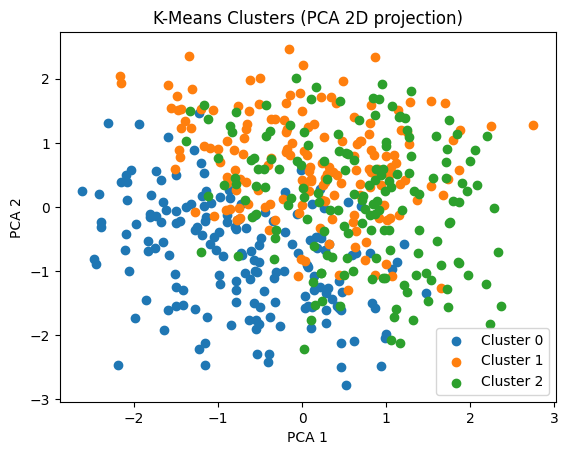

In [12]:
# ---------------------------------
# K-MEANS WITH SELECTED K & PCA VISUALIZATION
# ---------------------------------
# After looking at the elbow plot, set k_opt to the chosen number of clusters.
k_opt = 3  # <- update based on elbow result

kmeans = KMeans(n_clusters=k_opt, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

df["cluster"] = cluster_labels
print("Cluster counts:")
print(df["cluster"].value_counts())

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
for c in range(k_opt):
    plt.scatter(
        X_pca[cluster_labels == c, 0],
        X_pca[cluster_labels == c, 1],
        label=f"Cluster {c}"
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters (PCA 2D projection)")
plt.legend()
plt.show()


In [13]:
# ---------------------------------
# CLUSTER PROFILES
# ---------------------------------
cluster_profiles = df.groupby("cluster").mean(numeric_only=True)
cluster_profiles

,Age,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Outcome
cluster,,,,,,,
0,48.255814,30.996512,119.482558,135.372093,192.290698,94.924419,0.482558
1,59.789157,29.895181,127.469880,120.295181,268.542169,88.771084,0.542169
2,41.543210,25.796914,126.481481,143.740741,226.759259,71.228395,0.543210


In [ ]:
# ---------------------------------
# ASSOCIATION RULE MINING (APRIORI)
# ---------------------------------
# Choose a few categorical columns that are meaningful for pattern mining.
# Update this list to match your dataset.
cat_cols = []  # e.g., ["Diagnosis", "TreatmentPlan", "RiskLevel"]

if len(cat_cols) == 0:
    print("No categorical columns specified for association rule mining. "
          "Update 'cat_cols' with relevant column names from the dataset.")
else:
    df_cat = df[cat_cols].astype(str)

    # Convert rows into transactions
    transactions = df_cat.apply(
        lambda row: [f"{col}={row[col]}" for col in df_cat.columns],
        axis=1
    ).tolist()

    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    basket_df = pd.DataFrame(te_ary, columns=te.columns_)

    print("Basket (one-hot) data shape:", basket_df.shape)
    display(basket_df.head())

    # Apriori to get frequent itemsets
    frequent_itemsets = apriori(
        basket_df,
        min_support=0.05,  # adjust as needed
        use_colnames=True
    )

    print("Top frequent itemsets:")
    display(frequent_itemsets.sort_values("support", ascending=False).head(10))

    # Association rules
    rules = association_rules(
        frequent_itemsets,
        metric="lift",
        min_threshold=1.0
    )

    rules_sorted = rules.sort_values("lift", ascending=False)
    print("Top association rules:")
    display(rules_sorted.head(10))


No categorical columns specified for association rule mining. Update 'cat_cols' with relevant column names from your dataset.
